# Modelatge
En aquest notebook aplicarem models d'aprenentatge no supervisats de clustering per agrupar els barris segons les seves característiques. 

**to do**
-  Preprocess
    - Log Transf\
Tal i com hem comentat en eda, algunes variables amb valor absoluts, presenten valors extrems. Per tal de reduir el seu efecte en clustering, aplicarem transformacions logarítmiques.
        - df_2015:
            - total_incidents_1000_hab
            - locals_restauracio_1000_hab
        - df_2023:
            - total_incidents_1000_hab
            - locals_serveis_professionals_1000_hab

    - Winsorization\
En relació als valors extrems esmentats anteriorment, els deltes calculats a partir d'aquests també queden exposats a aquest efecte. Dondad la naturalesa de les variacions (-inf, +inf) no podem aplicar transformació logarítmica directament. Per tant aplicarem tècnica de windsorization, per capar els valors extrems i imputar-los amb uns valors menys extrems (98%).
        - df_deltes
            - delta_locals_serveis_professionals_1000_hab
            - delta_pisos_turistics_1000_hab
            - delta_poblacio_total (tbc)
            - delta_pct_pob_estrangera
            - delta_locals_restauracio_1000_hab

-  StandardScaler
-  PCA
-  Models
    - Kmeans
    - AglomerativeClustering

- Conclusions i resultats

**Funcions a definir:**
- funcio per aplicar transf logarítmica a certes variables
- funcio per aplicar winsoring
- funcio per gràficar pca i variança explicada
- funcio per silouette i inercia
- funcio per kmeans i graficar clusters
- funcio per agglomerative i graficar clusters
- funcio per els clusters en mapa






# Llibreries i configuracio

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from shapely import wkt
import geopandas as gpd


# Evitar warning
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

from matplotlib.ticker import FixedLocator, FixedFormatter
sns.set_theme()

# Carrega dels datasets

In [2]:
BASE_DIR = Path('..')
DATA_DIR = BASE_DIR/'data'
RESULTS_DIR = BASE_DIR/'results'/'figs'


df_2015 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2015.csv')
df_2023 = pd.read_csv(DATA_DIR / 'modelling' / 'df_2023.csv')
df_deltes = pd.read_csv(DATA_DIR / 'modelling' / 'df_deltes.csv')

dim_barris = pd.read_csv(DATA_DIR / 'dimensions' / 'BarcelonaCiutat_Barris.csv')

print("Dataset 2015: ", df_2015.shape)
print("Dataset 2023: ", df_2023.shape)
print("Dataset Deltes: ", df_deltes.shape)

Dataset 2015:  (73, 14)
Dataset 2023:  (73, 14)
Dataset Deltes:  (73, 14)


# Funcions auxiliars 

In [ ]:
def transformacio_logaritmica(df: pd.DataFrame, columnes: list):
    df_mod = df.copy()
    for c in columnes:
        if (df_mod[c] < 0).any():
            raise ValueError(f"La columna {c} té valors negatius. No es pot aplicar log1p.")
        
        df_mod[c] = np.log1p(df_mod[c])
    return df_mod

def transformacio_winsor(df: pd.DataFrame, columnes: list, low: float, high: float):
    df_mod = df.copy()
    for c in columnes:
        lower = df_mod[c].quantile(low)
        upper = df_mod[c].quantile(high)
        
        df_mod[c] = df_mod[c].clip(lower, upper)
    
    return df_mod

def extreure_codi_barri(df:pd.DataFrame): 
    codi_barri = df["codi_barri"]
    X = df[[col for col in df.columns if col != "codi_barri"]].copy()
    return codi_barri, X


def grafic_var_explicada(pca: np.array, target: float, titol: str, nom_arxiu: str):
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumsum >= target) + 1
    var_explicada = pca.explained_variance_ratio_
    
    plt.figure(figsize=(6,3))
    plt.bar(range(1, len(var_explicada)+1), var_explicada, alpha=0.6, label="Var Explicada")
    plt.plot(range(1, len(var_explicada)+1), cumsum, linewidth=1, marker = 'o', label= "Var Explicada Cum",c ="r")
    plt.axhline(0.95, color='green', linestyle='--', label='95%')
    plt.plot([n_components, n_components], [0, target], "k:")
    plt.plot([0, n_components], [target, target], "k:")
    plt.plot(n_components, target, "ko")
    plt.xlabel("Dimensions")
    plt.ylabel("Explained Variance")
    plt.title(f"{titol} | n_components = {n_components}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_arxiu}")
    plt.show()


def evaluate_kmeans(X:np.ndarray, min:int, max:int) -> dict:
    inercies = []
    silhouettes = []
    models = []
    for k in range(min, max):
        kmean = KMeans(n_clusters=k, n_init=20, random_state= 42).fit(X)
        models.append(kmean)
        inercies.append(kmean.inertia_)
        if len(models) > 1:
            silhouettes.append(silhouette_score(X, kmean.labels_))
    return {"models": models, "inercies": inercies, "silhouettes": silhouettes}


def consolidacio_resultats_seleccio_kmeans(resultats: dict)->pd.DataFrame:
    rows = []

    for tipus in ["pca", "escalades"]:
        for i, k in enumerate(resultats["n_clusters"]):
            rows.append({
                "n_clusters": k,
                "tipo_dades": tipus,
                "inercia": resultats[tipus]["inercies"][i],
                "silhouette": None if k == 1 else resultats[tipus]["silhouettes"][i - 1]
            })

    return pd.DataFrame(rows)

def plot_seleccio_kmeans(results_dict: dict, nom_dades: str, nom_fitxer: str) -> None:
    results = consolidacio_resultats_seleccio_kmeans(results_dict)
    fig = plt.figure(figsize=(8, 5))
    ax1 = fig.add_subplot(2, 1, 1)
    ax2 = fig.add_subplot(2, 1, 2)
    sns.lineplot(results, y = "inercia", x = "n_clusters", hue = "tipo_dades", ax=ax1, style="tipo_dades", markers=['o', 'D'])
    sns.lineplot(results, y = "silhouette", x = "n_clusters", hue = "tipo_dades", ax= ax2, style="tipo_dades", markers = ['o', 'D'])
    plt.suptitle(f"Selecció de k amb KMeans ({nom_dades})")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_fitxer}")
    plt.show()

def plot_silhouettes(kmeans_per_k:list[KMeans], silhouette_scores: list[float], X:np.ndarray, nom_fitxer:str):
    plt.figure(figsize = (11,9))
    for k in (3, 4, 5, 6):
        plt.subplot(2, 2, k - 2)
        y_pred = kmeans_per_k[k - 1].labels_
        silhouette_coefficients = silhouette_samples(X, y_pred)

        padding = len(X) // 30
        pos = padding
        ticks = []
        for i in range(k):
            coeffs = silhouette_coefficients[y_pred == i]
            coeffs.sort()

            color = plt.cm.Spectral(i / k)
            plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                            facecolor=color, edgecolor=color, alpha=0.7)
            ticks.append(pos + len(coeffs) // 2)
            pos += len(coeffs) + padding

        plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
        plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
        if k in (3, 5):
            plt.ylabel("Cluster")
        
        if k in (5, 6):
            plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
            plt.xlabel("Silhouette Coefficient")
        else:
            plt.tick_params(labelbottom=False)

        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
        plt.title(f"$k={k}$")
        plt.savefig(RESULTS_DIR / f"{nom_fitxer}")
        plt.show()


def plot_seleccio_agg(results: pd.DataFrame, nom_dades: str, nom_fitxer: str):
    plt.figure(figsize=(8, 3))
    sns.lineplot(results, y = "silhouette", x = "n_clusters", hue = "tipo_dades", style="tipo_dades", markers = ['o', 'D'])
    plt.title(f"Selecció de K amb Silhouette amb Agglomerative Clustering ({nom_dades})")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{nom_fitxer}")
    plt.show()

def plot_clusters(df: pd.DataFrame, titol: str, nom_fitxer: str, dir: str=RESULTS_DIR):
    dim_barris["geometry"] = dim_barris["geometria_wgs84"].apply(wkt.loads)
    gdf = gpd.GeoDataFrame(dim_barris, geometry="geometry", crs="EPSG:4326")
    gdf = gdf.merge(df[["codi_barri", "cluster"]], on="codi_barri", how="left")
    gdf.plot(
        column="cluster",
        categorical=True,
        legend=True,
        figsize=(8, 8),
        edgecolor="black",
        cmap="Accent",
        linewidth=0.3
    )
    plt.title(titol)
    plt.axis("off")
    plt.savefig(dir / f"{nom_fitxer}")
    plt.show()

def df_to_markdown(df):
    return pd.io.clipboards.to_clipboard(df.to_markdown(), excel=False)

# Preprocessament Comuns
- Separar variables de codi_barri
- Aplicar transformacions per outliers (logs o winsor)
- Escalar els conjunts de dades
- Aplicar PCA
- Aplicar clustering amb pca i amb escalat
- Seleccionar nombre de clusters
- Interpretació dels clústers

In [4]:
# Separem la columna de codi barri
codi_barri_15, X_15 = extreure_codi_barri(df_2015)
codi_barri_23, X_23 = extreure_codi_barri(df_2023)
codi_barri_deltes, X_deltes = extreure_codi_barri(df_deltes)

In [5]:
logs_2015 = ["total_incidents_1000_hab","locals_restauracio_1000_hab"]
logs_2023 = ["total_incidents_1000_hab", "locals_serveis_professionals_1000_hab"]
caps_deltes = ["delta_locals_serveis_professionals_1000_hab", "delta_pisos_turistics_1000_hab", "delta_poblacio_total", "delta_locals_restauracio_1000_hab", "delta_pct_pob_estrangera"]

X_15_logs = transformacio_logaritmica(X_15, logs_2015)
X_23_logs = transformacio_logaritmica(X_23, logs_2023)
X_deltes_logs = transformacio_winsor(X_deltes, caps_deltes, 0.2, 0.98)

In [6]:
# Escalem les dades
scaler = StandardScaler()

X_15_scaled = scaler.fit_transform(X_15_logs)
X_23_scaled = scaler.fit_transform(X_23_logs)
X_deltes_scaled = scaler.fit_transform(X_deltes_logs)

# Dades 2015

## PCA (Principal Component analysis)

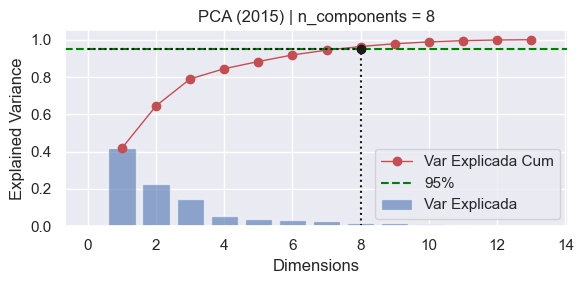

In [7]:
# Probarem PCA per reduir la dimensionalitat del conjunt de dades
pca_15 = PCA(random_state= 42)
pca_embedding = pca_15.fit_transform(X_15_scaled)
grafic_var_explicada(pca_15, 0.95, "PCA (2015)", "variança_explicada_15.png")

**Observacions:**
- 8 components per explicar el 95% de la variança de les dades. 
- Els tres principals components ja expliquen el 80% de la variança.

In [8]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_15 = np.argmax(np.cumsum(pca_15.explained_variance_ratio_) > 0.95) + 1

pca_15_fixed = PCA(n_components= n_components_15, random_state= 42)
X_pca_15_fixed = pca_15_fixed.fit_transform(X_15_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_15_fixed, columns=[f'PC{i}' for i in range(1, n_components_15 + 1)], index=df_2015['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
codi_barri,,,,,,,,
1,2.394009,4.551549,-1.515259,-2.319701,-0.199694,-0.956043,-0.042642,-0.262777
2,4.660526,6.204773,1.416379,-0.214522,-0.299504,0.124399,1.004626,-0.431889
3,2.745476,3.621419,1.370914,-0.257690,0.378690,-1.440013,1.603773,1.508977
4,4.263242,4.804871,0.842041,-0.365299,-0.335171,-1.050842,0.424999,-0.024162
5,1.967797,0.485187,-0.753469,0.790520,0.604716,0.161401,-0.657244,-0.241522


## Anàisi components PCA

## KMeans

In [9]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
resultats_clusters_2015 = []
for k in valors_k:
    clusterer_scaled = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_scaled = clusterer_scaled.fit_predict(X_15_scaled)
    resultats_clusters_2015.append(evaluacio_cluster(clusterer_scaled, X_15_scaled, cluster_labels_scaled, f"KMeans_{k}", "escalades"))

    clusterer_pca = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_pca = clusterer_pca.fit_predict(X_pca_15_fixed)
    resultats_clusters_2015.append(evaluacio_cluster(clusterer_pca, X_pca_15_fixed, cluster_labels_pca, f"KMeans_{k}", "pca"))


# Convertim a dataframe
resultats_2015_df = pd.DataFrame(resultats_clusters_2015)
resultats_2015_df

,model,tipo_dades,n_clusters,silhouette,inercia
0,KMeans_2,escalades,2,0.291655,646.724781
1,KMeans_2,pca,2,0.303156,612.291648
2,KMeans_3,escalades,3,0.309027,523.669004
3,KMeans_3,pca,3,0.322967,489.282094
4,KMeans_4,escalades,4,0.290372,446.282843
5,KMeans_4,pca,4,0.307173,411.973114
6,KMeans_5,escalades,5,0.257107,368.391474
7,KMeans_5,pca,5,0.284329,334.970196
8,KMeans_6,escalades,6,0.242146,335.508731
9,KMeans_6,pca,6,0.266021,301.026980


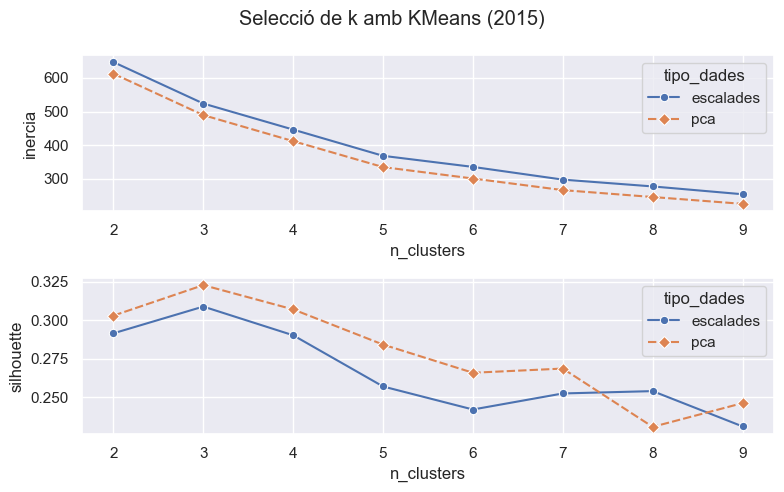

In [10]:
plot_seleccio_kmeans(resultats_2015_df, "2015", "seleccio_k_2015.png")

**Observacions:**
- El nombre òptim de clusters segons el valor de silhouette és 3, encara que amb 4 cluster s' obté un resultat força bai,x
- Els valors de silhouette són fluixos, indicant que els clusters no seran tant diferenciats.
- Els resultats milloren lleugerament amb pca.

## Agglomerative Clustering

In [11]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
agg_resultats_15 = []
for k in valors_k:
    agg_scaled = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_scaled.fit_predict(X_15_scaled)
    agg_resultats_15.append(evaluacio_cluster(agg_scaled, X_15_scaled, agg_labels, f"Agglomeratiu_{k}", "escalades"))

    agg_pca = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_pca.fit_predict(X_pca_15_fixed)
    agg_resultats_15.append(evaluacio_cluster(agg_pca, X_pca_15_fixed, agg_labels, f"Agglomeratiu_{k}", "pca"))


# Convertim a dataframe
agg_resultats_15_df = pd.DataFrame(agg_resultats_15)
agg_resultats_15_df

,model,tipo_dades,n_clusters,silhouette
0,Agglomeratiu_2,escalades,2,0.291655
1,Agglomeratiu_2,pca,2,0.307424
2,Agglomeratiu_3,escalades,3,0.309027
3,Agglomeratiu_3,pca,3,0.323764
4,Agglomeratiu_4,escalades,4,0.291629
5,Agglomeratiu_4,pca,4,0.187225
6,Agglomeratiu_5,escalades,5,0.252424
7,Agglomeratiu_5,pca,5,0.208987
8,Agglomeratiu_6,escalades,6,0.219023
9,Agglomeratiu_6,pca,6,0.218996


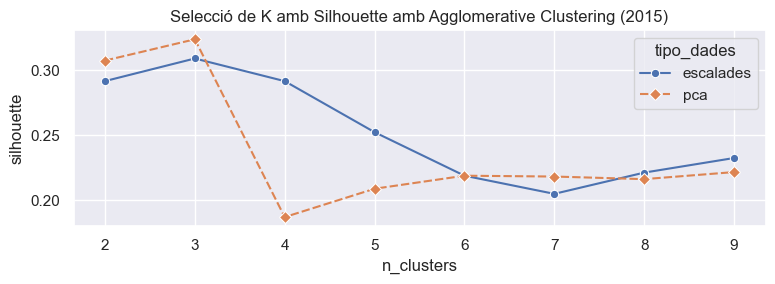

In [12]:
plot_seleccio_agg(agg_resultats_15_df, "2015", "seleccio_k_2015_agg.png")

**Observacions:**
- Scores de silhouette similars a les obtingudes amb KMeans, i amb millor score amb k=3, encara que k=2 obté resultats similars. 
- En aquest cas també, pca obté resultats lleugerament superiors. 

## Decisió i conclusions

In [30]:
conclusions_df23 = {"clusters": "k=3", 
                    "model": "kmeans",
                    "tipo_dades": "pca",
                    "comentari": "Tant per a KMeans com Agglomerative, i amb mètode de colze i valors de silhouette, el nombre òptim de cluster és k=3. Utilitzarem kmeans per interpretabilitat i coneixements ja que Agglomerative no millora substancialment el clustering."}

pd.DataFrame([conclusions_df23])

,clusters,model,tipo_dades,comentari
0,k=3,kmeans,pca,"Tant per a KMeans com Agglomerative, i amb mèt..."


## Clustering

In [25]:
# Apliquem kmeans
k_15 = 4
kmeans_15_final = KMeans(n_clusters= k_15, random_state= 42, n_init = 20)
kmeans_15_final_labels = kmeans_15_final.fit_predict(X_pca_15_fixed)

# Obtenim codi de barri i cluster
clustered = df_2015[["codi_barri"]].copy()
clustered['cluster'] = kmeans_15_final_labels
clustered.head()


,codi_barri,cluster
0,1,0
1,2,0
2,3,0
3,4,0
4,5,2


In [26]:
# Obtenim info dels clusters 
print("Distribucins de clusters:\n", clustered["cluster"].value_counts() )
print("\nPerfils: ")
perfils_15 = df_2015.merge(clustered, on = "codi_barri", how = "right")
perfils_15.groupby("cluster").mean().T


Distribucins de clusters:
 cluster
1    40
2    16
3    13
0     4
Name: count, dtype: int64

Perfils: 


cluster,0,1,2,3
codi_barri,2.500000,46.800000,30.000000,26.076923
poblacio_total,25042.250000,15813.475000,35124.125000,23846.615385
pct_pob_estrangera,0.401387,0.133358,0.175897,0.126322
pct_pob_estrangera_occidental,0.162695,0.024349,0.065328,0.065280
pct_joves,0.399800,0.263827,0.295617,0.246601
pct_universitaris,0.264166,0.141535,0.287426,0.379472
import_euros,10615.768038,11779.621896,15063.089836,21017.075429
index_gini,37.973881,31.189503,33.908692,36.999989
total_incidents_1000_hab,30.457174,52.024721,18.134005,28.966433
locals_restauracio_1000_hab,19.001463,3.121797,7.177124,5.522285


In [27]:
df_to_markdown(perfils_15.groupby("cluster").mean().T)

|                                       |            0 |             1 |            2 |
|:--------------------------------------|-------------:|--------------:|-------------:|
| codi_barri                            |    27.7667   |    47.641     |     2.5      |
| poblacio_total                        | 29412.1      | 15953         | 25042.2      |
| pct_pob_estrangera                    |     0.154681 |     0.132063  |     0.401387 |
| pct_pob_estrangera_occidental         |     0.065206 |     0.0233761 |     0.162695 |
| pct_joves                             |     0.274368 |     0.263019  |     0.3998   |
| pct_universitaris                     |     0.325844 |     0.138924  |     0.264166 |
| import_euros                          | 17606.9      | 11723.3       | 10615.8      |
| index_gini                            |    35.2065   |    31.1519    |    37.9739   |
| total_incidents_1000_hab              |    23.3421   |    52.4983    |    30.4572   |
| locals_restauracio_1000_hab           |     6.33007  |     3.11778   |    19.0015   |
| locals_sanitaris_1000_hab             |     1.08571  |     0.409403  |     0.323594 |
| locals_serveis_professionals_1000_hab |     1.39396  |     0.828169  |     0.600092 |
| preu_mitja_m2                         |    11.8433   |     8.99231   |    12.825    |
| pisos_turistics_1000_hab              |     6.85932  |     0.607512  |     6.96934  |

In [28]:
barris_clusters_15 = dim_barris[["codi_barri", "nom_barri"]].copy()
barris_clusters_15_merged = barris_clusters_15.merge(clustered, on = "codi_barri", how = "left")

for c in set(barris_clusters_15_merged["cluster"]):
    print(f"\nBarris en cluster {c}:")
    print(barris_clusters_15_merged["nom_barri"][barris_clusters_15_merged["cluster"] == c].unique())
    print("*"*50)


Barris en cluster 0:
['el Raval' 'el Barri Gòtic' 'la Barceloneta'
 'Sant Pere, Santa Caterina i la Ribera']
**************************************************

Barris en cluster 1:
['la Marina del Prat Vermell' 'la Marina de Port' 'la Font de la Guatlla'
 'la Bordeta' 'Sants - Badal' 'el Coll' 'Can Baró' "la Font d'en Fargues"
 'el Carmel' 'la Teixonera' 'Sant Genís dels Agudells' 'Montbau'
 "la Vall d'Hebron" 'la Clota' 'Horta' 'Vilapicina i la Torre Llobeta'
 'Porta' 'el Turó de la Peira' 'Can Peguera' 'la Guineueta' 'Canyelles'
 'les Roquetes' 'Verdun' 'la Prosperitat' 'la Trinitat Nova' 'Torre Baró'
 'Ciutat Meridiana' 'Vallbona' 'la Trinitat Vella' 'Baró de Viver'
 'el Bon Pastor' 'Sant Andreu' 'la Sagrera' 'el Congrés i els Indians'
 'Navas' 'el Clot' 'el Besòs i el Maresme' 'Provençals del Poblenou'
 'Sant Martí de Provençals' 'la Verneda i la Pau']
**************************************************

Barris en cluster 2:
['el Fort Pienc' 'la Sagrada Família' "l'Antiga Esquerra

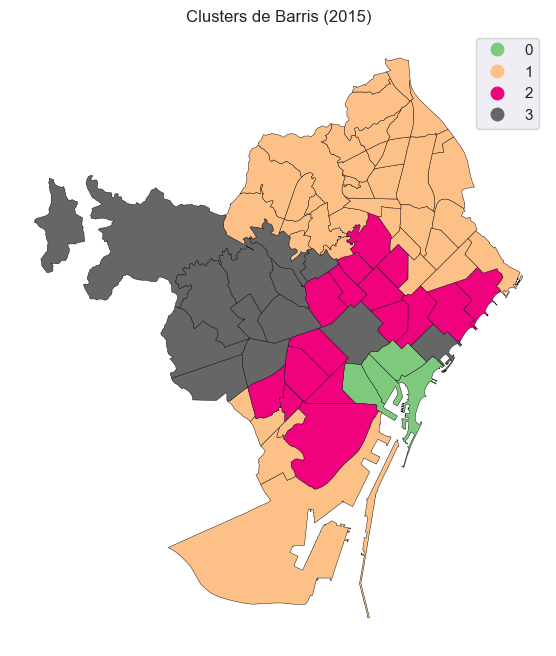

In [29]:
plot_clusters(clustered, "Clusters de Barris (2015)", "clusters_15_2.png")

In [36]:
perfils_15.to_csv(DATA_DIR / 'clustered' / 'df_2015.csv', index= False)

# Dades 2023

## PCA (Principal Component Analysisi)

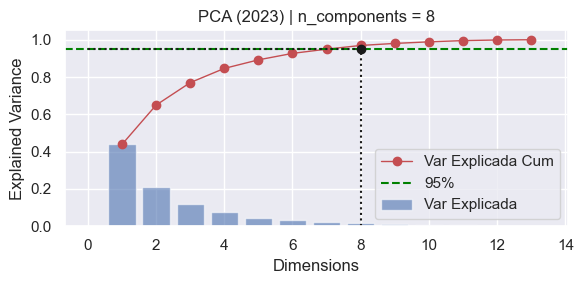

In [37]:
pca_23 = PCA(random_state= 42)
pca_embedding = pca_23.fit_transform(X_23_scaled)
grafic_var_explicada(pca_23, 0.95, "PCA (2023)", "variança_explicada_23.png")

**Observacions:**
- Per al dataset de 2023 el nombre de dimensions necessari per explicar el 95% de la variança són 8

In [38]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_23 = np.argmax(np.cumsum(pca_23.explained_variance_ratio_) > 0.95) + 1

pca_23_fixed = PCA(n_components= n_components_23, random_state= 42)
X_pca_23_fixed = pca_23_fixed.fit_transform(X_23_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_23_fixed, columns=[f'PC{i}' for i in range(1, n_components_23 + 1)], index=df_2023['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
codi_barri,,,,,,,,
1,2.279588,3.895755,0.532555,-1.569706,-0.439043,-0.896257,0.214921,-0.009310
2,4.617444,6.031876,-1.815871,-1.039161,-1.356210,-0.571358,0.530613,0.426491
3,3.060700,3.392185,-1.974732,0.106278,-0.163602,-0.581584,-1.488165,0.570237
4,4.674134,4.093708,-2.075445,-0.324293,-0.279745,-0.335467,-0.825599,-0.769719
5,2.118740,1.080636,0.494154,0.111880,0.864906,-0.080071,0.637641,-0.034132


## KMeans

In [39]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
resultats_clusters_2023 = []
for k in valors_k:
    clusterer_scaled = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_scaled = clusterer_scaled.fit_predict(X_23_scaled)
    resultats_clusters_2023.append(evaluacio_cluster(clusterer_scaled, X_23_scaled, cluster_labels_scaled, f"KMeans_{k}", "escalades"))

    clusterer_pca = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_pca = clusterer_pca.fit_predict(X_pca_23_fixed)
    resultats_clusters_2023.append(evaluacio_cluster(clusterer_pca, X_pca_23_fixed, cluster_labels_pca, f"KMeans_{k}", "pca"))


# Convertim a dataframe
resultats_2023_df = pd.DataFrame(resultats_clusters_2023)
resultats_2023_df

,model,tipo_dades,n_clusters,silhouette,inercia
0,KMeans_2,escalades,2,0.326887,634.605402
1,KMeans_2,pca,2,0.336898,605.731942
2,KMeans_3,escalades,3,0.319016,526.653853
3,KMeans_3,pca,3,0.307050,497.653525
4,KMeans_4,escalades,4,0.309884,450.638067
5,KMeans_4,pca,4,0.323041,421.924845
6,KMeans_5,escalades,5,0.226534,383.398273
7,KMeans_5,pca,5,0.239452,357.627443
8,KMeans_6,escalades,6,0.252278,344.144208
9,KMeans_6,pca,6,0.244193,314.819515


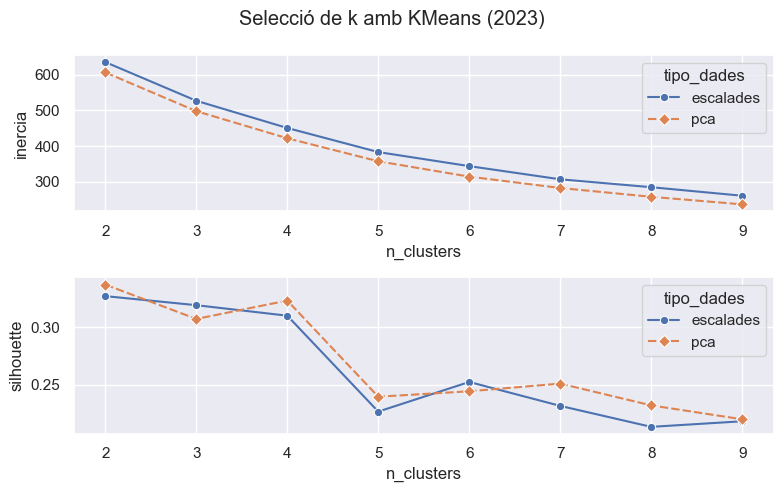

In [40]:
plot_seleccio_kmeans(resultats_2023_df, "2023", "seleccio_k_2023.png")

**Observacions:**
- Els resultats de Silhouette indiquen o bé 2 o 4 clusters és el nombre òptim. Si ens basem en el mètode del colze, 4 és un bon candidat per a ser el nombre de k.

## Agglomerative Clustering

In [41]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
agg_resultats_23 = []
for k in valors_k:
    agg_scaled = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_scaled.fit_predict(X_23_scaled)
    agg_resultats_23.append(evaluacio_cluster(agg_scaled, X_23_scaled, agg_labels, f"Agglomeratiu_{k}", "escalades"))

    agg_pca = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_pca.fit_predict(X_pca_23_fixed)
    agg_resultats_23.append(evaluacio_cluster(agg_pca, X_pca_23_fixed, agg_labels, f"Agglomeratiu_{k}", "pca"))


# Convertim a dataframe
agg_resultats_23_df = pd.DataFrame(agg_resultats_23)
agg_resultats_23_df

,model,tipo_dades,n_clusters,silhouette
0,Agglomeratiu_2,escalades,2,0.317477
1,Agglomeratiu_2,pca,2,0.327630
2,Agglomeratiu_3,escalades,3,0.318167
3,Agglomeratiu_3,pca,3,0.329893
4,Agglomeratiu_4,escalades,4,0.308662
5,Agglomeratiu_4,pca,4,0.321221
6,Agglomeratiu_5,escalades,5,0.208448
7,Agglomeratiu_5,pca,5,0.230848
8,Agglomeratiu_6,escalades,6,0.226455
9,Agglomeratiu_6,pca,6,0.240337


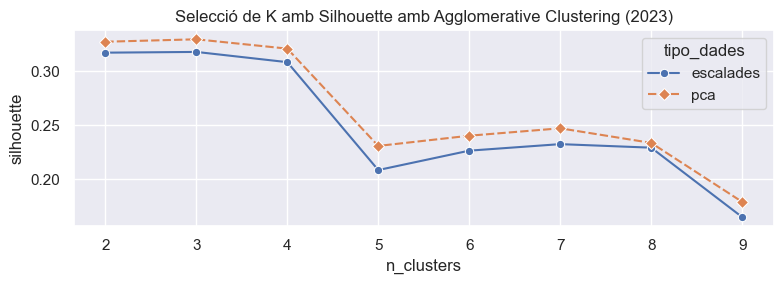

In [42]:
plot_seleccio_agg(agg_resultats_23_df, "2023", "seleccio_k_2023_agg.png")

**Observacions:**
- Amb agglomerative, el nombre ideal de clusters ñes entre 2 i 4.

## Decisió i conclusions

In [43]:
conclusions_df23 = {"clusters": "k=4", 
                    "model": "kmeans",
                    "tipo_dades": "pca",
                    "comentari": "Resultats  de Silhouette similars per a KMeans i Agglomerative. El nombre de clusters, pot estar entre 2 i 4 segons silhouette en KMeans. EN base al mètode del colze, seleccionarem k=4 i analitzarem els resultats."}

df_to_markdown(pd.DataFrame([conclusions_df23]))

## Clustering

In [44]:
# Apliquem kmeans
k_23 = 4
kmeans_23_final = KMeans(n_clusters= k_23, random_state= 42, n_init = 20)
kmeans_23_final_labels = kmeans_23_final.fit_predict(X_pca_23_fixed)

# Obtenim codi de barri i cluster
clustered_23 = df_2023[["codi_barri"]].copy()
clustered_23['cluster'] = kmeans_23_final_labels
clustered_23.head()


,codi_barri,cluster
0,1,3
1,2,3
2,3,3
3,4,3
4,5,1


In [45]:
# Obtenim info dels clusters 
print("Distribucins de clusters:\n", clustered_23["cluster"].value_counts() )
print("\nPerfils: ")
perfils_23 = df_2023.merge(clustered_23, on = "codi_barri", how = "right")
perfils_23.groupby("cluster").mean().T


Distribucins de clusters:
 cluster
2    41
1    17
0    11
3     4
Name: count, dtype: int64

Perfils: 


cluster,0,1,2,3
codi_barri,24.090909,29.411765,46.975610,2.500000
poblacio_total,23798.090909,33861.352941,17477.243902,26611.500000
pct_pob_estrangera,0.167663,0.261791,0.193395,0.513533
pct_pob_estrangera_occidental,0.068589,0.098404,0.033155,0.164410
pct_joves,0.238383,0.300125,0.255152,0.428441
pct_universitaris,0.424067,0.378786,0.191487,0.307910
import_euros,27788.443303,20775.291378,15475.124632,14977.917610
index_gini,36.277946,32.458638,28.808701,35.660057
total_incidents_1000_hab,31.271162,23.409614,55.007708,30.318418
locals_restauracio_1000_hab,4.492983,8.847777,3.179713,14.723694


In [46]:
barris_clusters_23 = dim_barris[["codi_barri", "nom_barri"]].copy()
barris_clusters_23_merged = barris_clusters_23.merge(clustered_23, on = "codi_barri", how = "left")

for c in set(barris_clusters_23_merged["cluster"]):
    print(f"\nBarris en cluster {c}:")
    print(barris_clusters_23_merged["nom_barri"][barris_clusters_23_merged["cluster"] == c].unique())
    print("*"*50)


Barris en cluster 0:
['les Corts' 'la Maternitat i Sant Ramon' 'Pedralbes'
 'Vallvidrera, el Tibidabo i les Planes' 'Sarrià' 'les Tres Torres'
 'Sant Gervasi - la Bonanova' 'Sant Gervasi - Galvany'
 'el Putxet i el Farró' 'Vallcarca i els Penitents' 'la Salut']
**************************************************

Barris en cluster 1:
['el Fort Pienc' 'la Sagrada Família' "la Dreta de l'Eixample"
 "l'Antiga Esquerra de l'Eixample" "la Nova Esquerra de l'Eixample"
 'Sant Antoni' 'el Poble-sec' 'la Font de la Guatlla' 'Hostafrancs'
 'Sants' 'la Vila de Gràcia' "el Camp d'en Grassot i Gràcia Nova"
 "el Camp de l'Arpa del Clot" 'el Parc i la Llacuna del Poblenou'
 'la Vila Olímpica del Poblenou' 'el Poblenou'
 'Diagonal Mar i el Front Marítim del Poblenou']
**************************************************

Barris en cluster 2:
['la Marina del Prat Vermell' 'la Marina de Port' 'la Bordeta'
 'Sants - Badal' 'el Coll' 'el Baix Guinardó' 'Can Baró' 'el Guinardó'
 "la Font d'en Fargues" 'el Ca

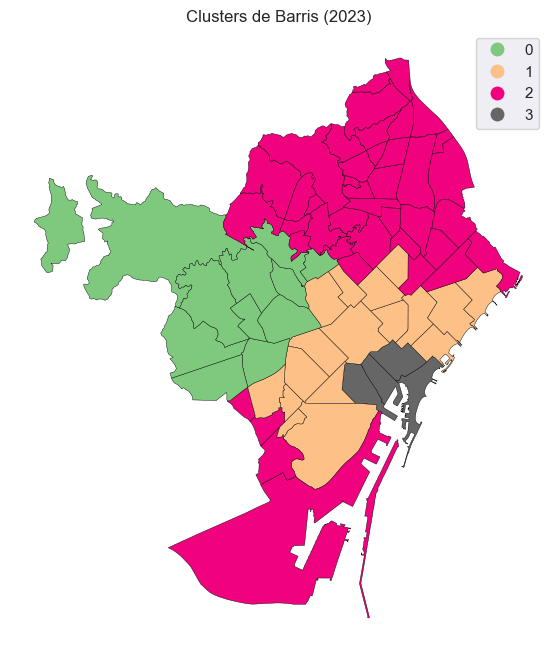

In [47]:
plot_clusters(clustered_23, "Clusters de Barris (2023)", "clusters_23 .png")

In [48]:
df_to_markdown(perfils_23.groupby("cluster").mean().T)

In [49]:
perfils_23.to_csv(DATA_DIR / 'clustered' / 'df_2023.csv', index= False)

# Deltes

## PCA (Principal component analysis)

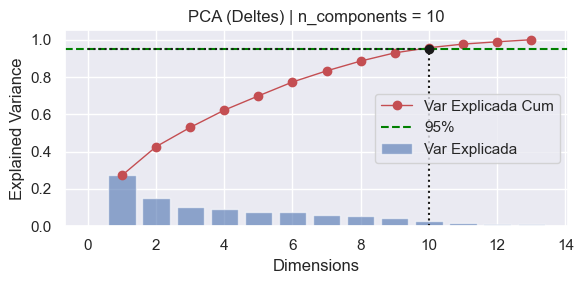

In [48]:
pca_deltes = PCA(random_state= 42)
pca_embedding = pca_deltes.fit_transform(X_deltes_scaled)
grafic_var_explicada(pca_deltes, 0.95, "PCA (Deltes)", "variança_explicada_deltes.png")

**Observacions:**
- Per al dataset de Deltes el nombre de dimensions necessari per explicar el 95% de la variança són 9 components

In [49]:
# apliquem pca amb el n_components obtingut anteriorment
n_components_deltes = np.argmax(np.cumsum(pca_deltes.explained_variance_ratio_) > 0.95) + 1

pca_deltes_fixed = PCA(n_components= n_components_deltes, random_state= 42)
X_pca_deltes_fixed = pca_deltes_fixed.fit_transform(X_deltes_scaled)

# Mostrem els resultats i components
X_pca_df = pd.DataFrame(X_pca_deltes_fixed, columns=[f'PC{i}' for i in range(1, n_components_deltes + 1)], index=df_deltes['codi_barri'])
X_pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
codi_barri,,,,,,,,,,
1,-0.712279,-1.017899,-0.957522,-0.788315,-0.221764,0.199416,-0.782956,0.038779,0.208456,0.286568
2,1.849738,1.691022,-0.217760,-4.721817,4.122428,-0.621379,-0.054605,0.230769,0.077089,0.474072
3,-0.495293,-0.143472,0.729172,-1.100068,-0.357392,0.117811,-2.497086,0.017309,1.037898,0.439561
4,-0.904120,-0.841458,0.188158,-1.116980,-0.143094,0.214789,-1.157916,0.011003,0.825308,0.129030
5,0.442518,0.935022,0.150729,-1.057134,0.738227,-0.040971,0.186709,-0.885834,0.615910,-0.406495


## KMeans

In [50]:
## KMeans
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
resultats_clusters_deltes = []
for k in valors_k:
    clusterer_scaled = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_scaled = clusterer_scaled.fit_predict(X_deltes_scaled)
    resultats_clusters_deltes.append(evaluacio_cluster(clusterer_scaled, X_deltes_scaled, cluster_labels_scaled, f"KMeans_{k}", "escalades"))

    clusterer_pca = KMeans(n_clusters = k, n_init = 20, random_state = 42)
    cluster_labels_pca = clusterer_pca.fit_predict(X_pca_deltes_fixed)
    resultats_clusters_deltes.append(evaluacio_cluster(clusterer_pca, X_pca_deltes_fixed, cluster_labels_pca, f"KMeans_{k}", "pca"))


# Convertim a dataframe
resultats_deltes_df = pd.DataFrame(resultats_clusters_deltes)
resultats_deltes_df

,model,tipo_dades,n_clusters,silhouette,inercia
0,KMeans_2,escalades,2,0.698805,749.488633
1,KMeans_2,pca,2,0.708104,709.330516
2,KMeans_3,escalades,3,0.276777,655.206728
3,KMeans_3,pca,3,0.297055,614.754875
4,KMeans_4,escalades,4,0.245699,598.848127
5,KMeans_4,pca,4,0.242285,542.093663
6,KMeans_5,escalades,5,0.244643,532.347568
7,KMeans_5,pca,5,0.152216,487.489065
8,KMeans_6,escalades,6,0.187112,481.681349
9,KMeans_6,pca,6,0.229283,450.309779


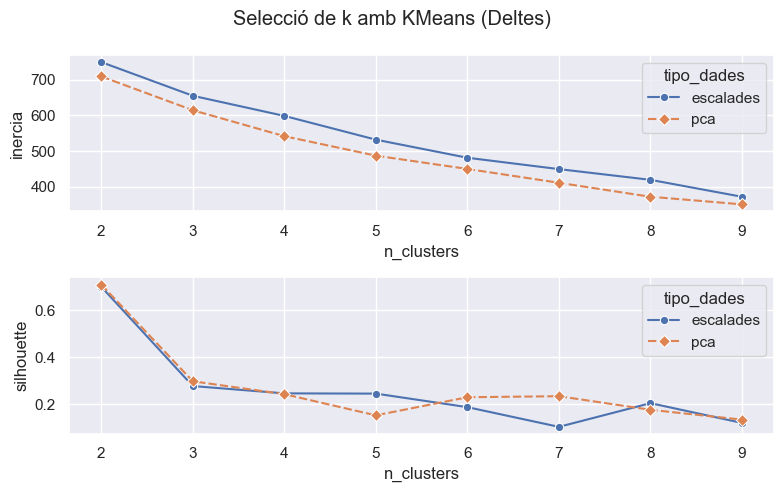

In [51]:
plot_seleccio_kmeans(resultats_deltes_df, "Deltes", "seleccio_k_deltes.png")

**Observacions:**
- Segons Silhouette, el nombre òptim de k és 3, i aniria amb sintonia amb el mètode del colze. k=2 i k=4 podrien ser candidats.
- PCA obté millors resultats.

## Agglomerative Clustering

In [54]:
# Comparem clusters amb pca vs dades escalades
valors_k = range(2, 10)
agg_resultats_deltes = []
for k in valors_k:
    agg_scaled = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_scaled.fit_predict(X_deltes_scaled)
    agg_resultats_deltes.append(evaluacio_cluster(agg_scaled, X_deltes_scaled, agg_labels, f"Aglomeratiu_{k}", "escalades"))

    agg_pca = AgglomerativeClustering(n_clusters = k)
    agg_labels = agg_pca.fit_predict(X_pca_deltes_fixed)
    agg_resultats_deltes.append(evaluacio_cluster(agg_pca, X_pca_deltes_fixed, agg_labels, f"Aglomeratiu_{k}", "pca"))


# Convertim a dataframe
agg_resultats_deltes_df = pd.DataFrame(agg_resultats_deltes)
agg_resultats_deltes_df

,model,tipo_dades,n_clusters,silhouette
0,Aglomeratiu_2,escalades,2,0.358143
1,Aglomeratiu_2,pca,2,0.369876
2,Aglomeratiu_3,escalades,3,0.352242
3,Aglomeratiu_3,pca,3,0.364030
4,Aglomeratiu_4,escalades,4,0.338770
5,Aglomeratiu_4,pca,4,0.351539
6,Aglomeratiu_5,escalades,5,0.128376
7,Aglomeratiu_5,pca,5,0.298722
8,Aglomeratiu_6,escalades,6,0.135294
9,Aglomeratiu_6,pca,6,0.116377


In [52]:
kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_pca_deltes_fixed)
                for k in range(1, 10)]
silhouette_scores = [silhouette_score(X_pca_deltes_fixed, model.labels_)
                     for model in kmeans_per_k[1:]]

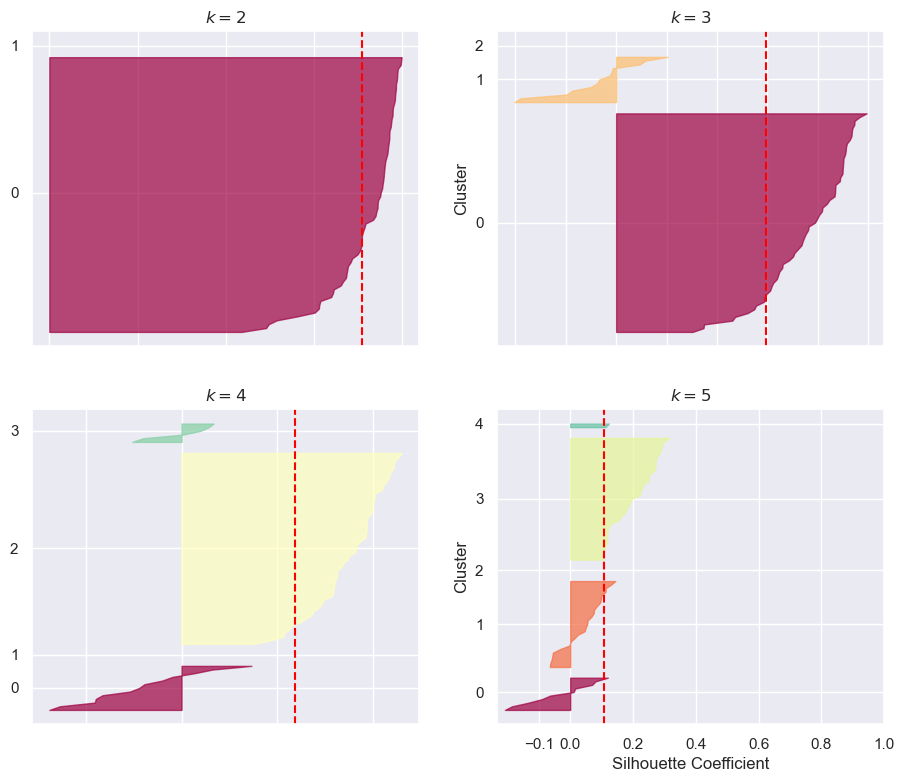

In [53]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
plt.figure(figsize = (11,9))

for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k - 1)
    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X_pca_deltes_fixed, y_pred)

    padding = len(X_pca_deltes_fixed) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")
    
    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$")

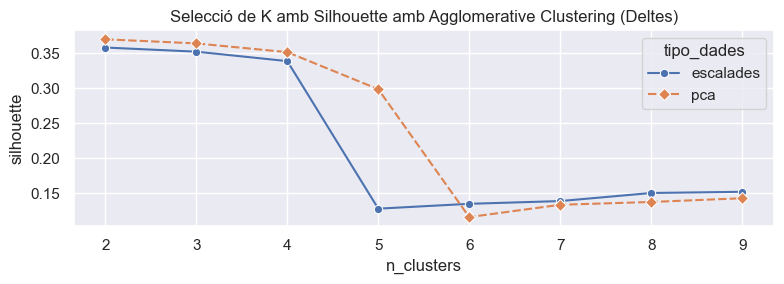

In [55]:
plot_seleccio_agg(agg_resultats_deltes_df, "Deltes", "seleccio_k_deltes_agg.png")

**Observacions:**
- Els resultats indiquen que el nombre de clusters optims per als deltes és entre 2 i 4, amb valors similars per pca i escalades.
- Els resultats són superiors als de KMeans en el cas de silhouette.

## Decisió i conclusions

In [56]:
conclusions_deltes = {"clusters": "k=3", 
                    "model": "kmeans",
                    "tipo_dades": "pca",
                    "comentari": "Ambós tècniques indiquen que k=3 és el nombre òptim de k. Per homogenitzar, utilitzarem KMeans com en la resta."}

df_to_markdown(pd.DataFrame([conclusions_deltes]))

## Clustering

In [62]:
# Apliquem kmeans
k_deltes = 2
kmeans_deltes_final = KMeans(n_clusters= k_deltes, random_state= 42, n_init = 20)
kmeans_deltes_final_labels = kmeans_deltes_final.fit_predict(X_pca_deltes_fixed)

# Obtenim codi de barri i cluster
clustered_deltes = df_deltes[["codi_barri"]].copy()
clustered_deltes['cluster'] = kmeans_deltes_final_labels
clustered_deltes.head()


,codi_barri,cluster
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [63]:
# Obtenim info dels clusters 
print("Distribucins de clusters:\n", clustered_deltes["cluster"].value_counts() )
print("\nPerfils: ")
perfils_deltes = df_deltes.merge(clustered_deltes, on = "codi_barri", how = "right")
perfils_deltes.groupby("cluster").mean().T


Distribucins de clusters:
 cluster
0    72
1     1
Name: count, dtype: int64

Perfils: 


cluster,0,1
codi_barri,37.347222,12.000000
delta_pct_pob_estrangera,0.473662,0.985491
delta_pct_pob_estrangera_occidental,0.312052,3.423398
delta_pct_joves,-0.008369,-0.034585
delta_pct_universitaris,0.278445,2.179257
delta_poblacio_total,0.046397,0.495544
delta_import_euros,0.316995,0.568477
delta_index_gini,-0.062623,0.000000
delta_total_incidents_1000_hab,0.130803,-0.249872
delta_locals_restauracio_1000_hab,0.057803,0.050741


In [64]:
barris_clusters_deltes = dim_barris[["codi_barri", "nom_barri"]].copy()
barris_clusters_deltes_merged = barris_clusters_deltes.merge(clustered_deltes, on = "codi_barri", how = "left")

for c in set(barris_clusters_deltes_merged["cluster"]):
    print(f"\nBarris en cluster {c}:")
    print(barris_clusters_deltes_merged["nom_barri"][barris_clusters_deltes_merged["cluster"] == c].unique())
    print("*"*50)


Barris en cluster 0:
['el Raval' 'el Barri Gòtic' 'la Barceloneta'
 'Sant Pere, Santa Caterina i la Ribera' 'el Fort Pienc'
 'la Sagrada Família' "la Dreta de l'Eixample"
 "l'Antiga Esquerra de l'Eixample" "la Nova Esquerra de l'Eixample"
 'Sant Antoni' 'el Poble-sec' 'la Marina de Port' 'la Font de la Guatlla'
 'Hostafrancs' 'la Bordeta' 'Sants - Badal' 'Sants' 'les Corts'
 'la Maternitat i Sant Ramon' 'Pedralbes'
 'Vallvidrera, el Tibidabo i les Planes' 'Sarrià' 'les Tres Torres'
 'Sant Gervasi - la Bonanova' 'Sant Gervasi - Galvany'
 'el Putxet i el Farró' 'Vallcarca i els Penitents' 'el Coll' 'la Salut'
 'la Vila de Gràcia' "el Camp d'en Grassot i Gràcia Nova"
 'el Baix Guinardó' 'Can Baró' 'el Guinardó' "la Font d'en Fargues"
 'el Carmel' 'la Teixonera' 'Sant Genís dels Agudells' 'Montbau'
 "la Vall d'Hebron" 'la Clota' 'Horta' 'Vilapicina i la Torre Llobeta'
 'Porta' 'el Turó de la Peira' 'Can Peguera' 'la Guineueta' 'Canyelles'
 'les Roquetes' 'Verdun' 'la Prosperitat' 'la Trin

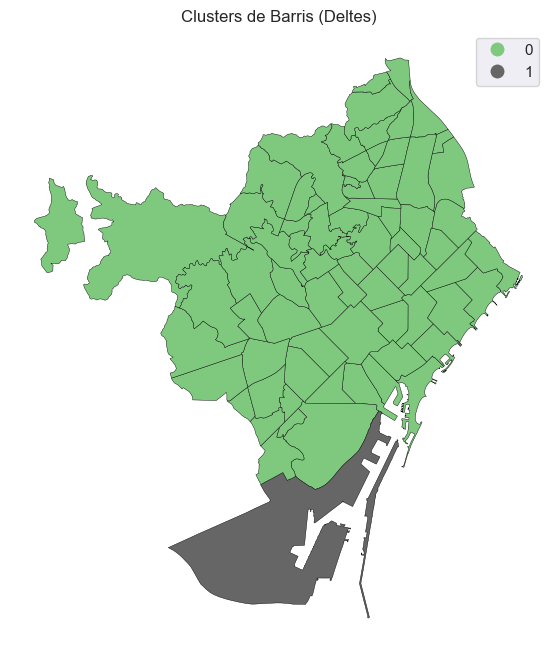

In [65]:
plot_clusters(clustered_deltes, "Clusters de Barris (Deltes)", "clusters_deltes.png")

In [61]:
df_to_markdown(perfils_deltes.groupby("cluster").mean().T)

In [62]:
perfils_deltes.to_csv(DATA_DIR / 'clustered' / 'df_deltes.csv', index= False)